In [ ]:
import os
os.environ['MUJOCO_GL'] = 'egl'

In [1]:
xml = """
<mujoco model="simple_pendulum">
    <option gravity="0 0 -9.81" timestep="0.01" integrator="RK4"/>

    <worldbody>
        <light diffuse=".5 .5 .5" pos="0 0 3" dir="0 0 -1"/>
        <camera name="track" mode="fixed" pos="0 -3.5 2.2" xyaxes="1 0 0 0 1 2" />

        <body name="anchor" pos="0 0 1.5">
            <geom type="sphere" size="0.05" rgba="1 1 1 1" contype="0" conaffinity="0"/>

            <body name="pole" pos="0 0 0">
                <joint name="swing_hinge" type="hinge" axis="0 1 0" pos="0 0 0" damping="0.7"/>
                <geom name="pole_geom" type="capsule" fromto="0 0 0 0 0 -1.0" size="0.045" rgba="0.9 0.2 0.2 1"/>
            </body>
        </body>
    </worldbody>
</mujoco>    
"""

In [ ]:
import mujoco
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

In [ ]:
# 3초간 60 프레임 (180장의 프레임)
duration = 3
framerate = 60
frames = []

data.qpos[0] = 0.5          # body의 위치정보 (각도... 라디안)

while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
        renderer.update_scene(data, camera="track")
        pixels = renderer.render()
        frames.append(pixels)

In [5]:
import numpy as np

def black_to_white(frame):
    result_frame = frame.copy()

    if len(result_frame.shape) == 3:
        black_pixels = np.all(result_frame == [0, 0, 0], axis=-1)
        result_frame[black_pixels] = [255, 255, 255]
    else:
        black_pixels = (result_frame == 0)
        result_frame[black_pixels] = 255

    return result_frame

In [ ]:
from IPython.display import Image, clear_output, display
import cv2

# 영상 출력
def display_image(frame):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, buffer = cv2.imencode('.jpg', frame)
    clear_output(wait=True)
    display(Image(data=buffer, width=500))

In [7]:
# 검은색 배경을 흰색으로 바꾸고 싶다면
def display_image_black_to_white(frame):
    frame = black_to_white(frame)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, buffer = cv2.imencode('.jpg', frame)
    clear_output(wait=True)
    display(Image(data=buffer, width=500))

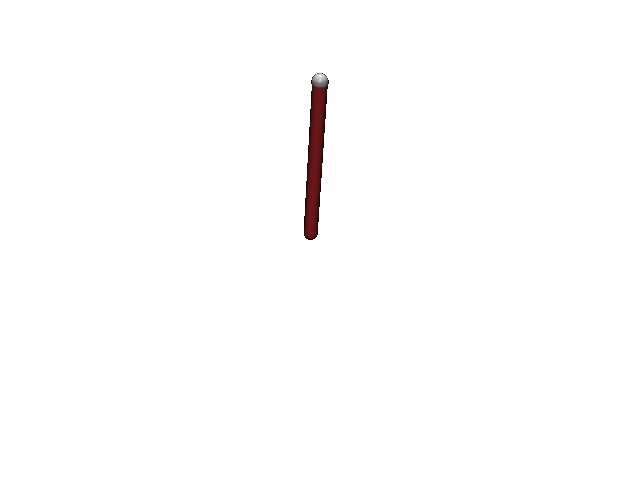

In [8]:
import time
for frame in frames:
    display_image_black_to_white(frame)
    time.sleep(1.0/framerate)

In [ ]:
# 상태 저장 및 관찰
def record_frame_and_data(renderer, data, frames_list, times_list, positions_list, velocities_list, camera_name="track"):
    # 씬업데이트 및 렌더링
    renderer.update_scene(data, camera=camera_name)
    pixels = renderer.render()

    # 프레임 및 데이터 저장
    frames_list.append(pixels)
    times_list.append(data.time)
    positions_list.append(data.qpos[0])
    velocities_list.append(data.qvel[0])


In [ ]:
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model)

duration = 10               # 초
framerate = 60              # fps

In [ ]:
frames = []
times = []
positions = []
velocities = []
data.qpos[0] = 0.5